# Coming from Nengo to nengo-dl

This tutorial is designed for people familiar with [Nengo](https://www.nengo.ai/) who
want to take advantage of the new features in **nengo-dl** (PyTorch backend).

For the complementary approach — users familiar with PyTorch looking to use nengo-dl — see the `from-pytorch` tutorial.

nengo-dl adds several new features on top of the standard Nengo simulator:

- **Drop-in replacement**: swap `nengo.Simulator` → `nengo_dl.Simulator` with no other changes
- **Batch processing**: run multiple input sequences in parallel (like batched inference in deep learning)
- **Optimizing parameters**: use gradient-based training to improve network accuracy
- **TorchNode**: embed arbitrary PyTorch `nn.Module`s directly inside a Nengo network

## Simulating a network with NengoDL

In [1]:
%matplotlib inline

import warnings

import matplotlib.pyplot as plt
import nengo
import numpy as np
import torch

import nengo_dl

warnings.simplefilter("ignore")

# control the random seed so results are reproducible
seed = 0
np.random.seed(seed)

In [2]:
with nengo.Network(seed=seed) as net:
    # input node outputting a random signal for x
    inpt = nengo.Node(nengo.processes.WhiteSignal(1, 5, rms=0.3))

    # first ensemble, will compute x^2
    square = nengo.Ensemble(20, 1)

    # second ensemble, will compute sin(x^2)
    sin = nengo.Ensemble(20, 1)

    # output node
    outpt = nengo.Node(size_in=1)

    # connect everything together
    nengo.Connection(inpt, square)
    nengo.Connection(square, sin, function=np.square)
    nengo.Connection(sin, outpt, function=np.sin)

    # add a probe on the input and output
    inpt_p = nengo.Probe(inpt)
    outpt_p = nengo.Probe(outpt, synapse=0.01)

We can simulate this network in the regular Nengo simulator:

In [3]:
with nengo.Simulator(net, seed=seed) as sim:
    sim.run(1.0)

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

And plot the output:

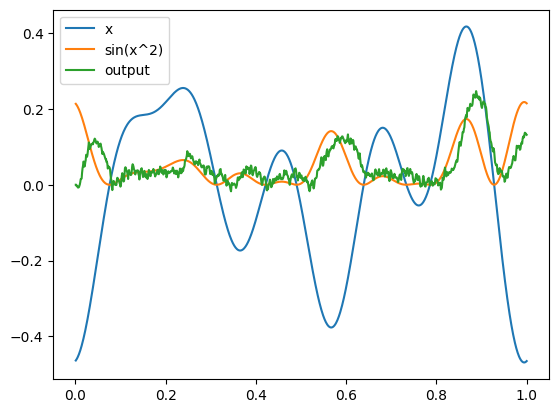

In [4]:
def plot(plot_sim, ax=None, idx=slice(None)):
    if ax is None:
        plt.figure()
        ax = plt.gca()
    ax.plot(plot_sim.trange(), plot_sim.data[inpt_p][idx], label="x")
    ax.plot(
        plot_sim.trange(), np.sin(plot_sim.data[inpt_p][idx] ** 2), label="sin(x^2)"
    )
    ax.plot(plot_sim.trange(), plot_sim.data[outpt_p][idx], label="output")
    ax.legend()


plot(sim)

To run the same network in nengo-dl, all we need to do is switch `nengo.Simulator` to
`nengo_dl.Simulator`:

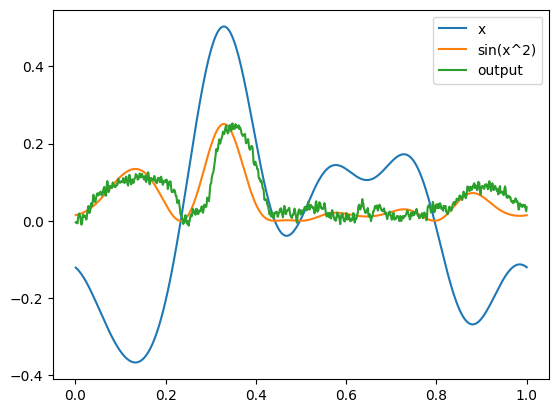

In [5]:
with nengo_dl.Simulator(net, seed=seed) as sim:
    sim.run(1.0)

plot(sim)

Note that the output of the nengo-dl simulator closely matches the standard Nengo
simulator — the PyTorch backend faithfully replicates the network dynamics.

> **Note on timing**: For small networks, the standard Nengo simulator (a highly
> optimized C backend) is typically *faster* than nengo-dl. The advantage of nengo-dl
> appears with larger networks, GPU acceleration, and — most importantly — batch
> processing, described next.

## Batch processing

Often when testing a model we want to run it several times with different input values.
In regular Nengo we can achieve this by calling `sim.run` several times, resetting
between each run:

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

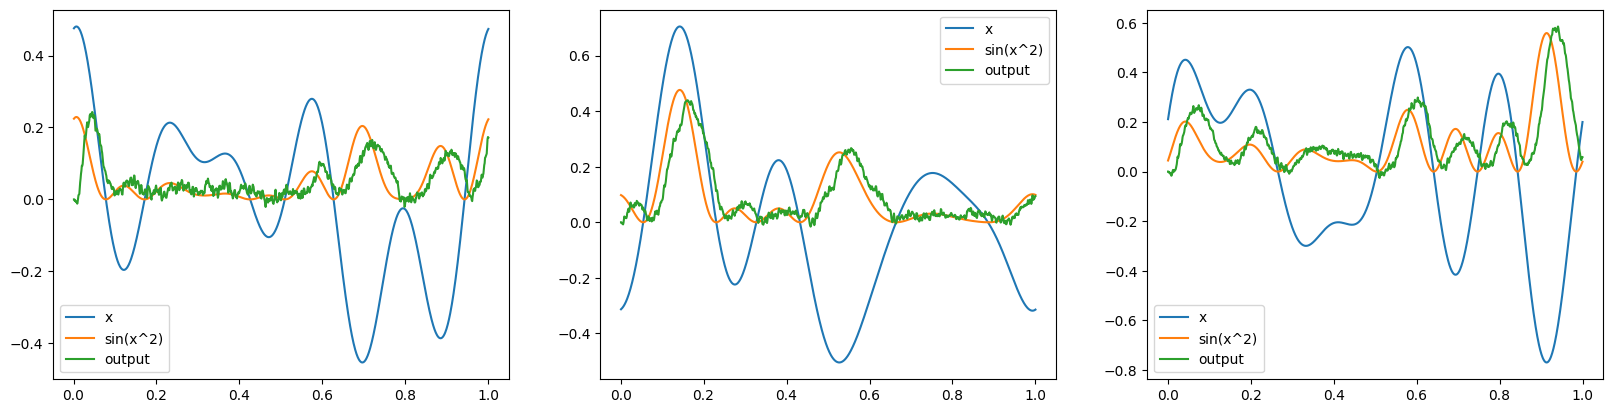

In [6]:
reps = 3

with nengo.Simulator(net) as sim:
    _, axes = plt.subplots(1, reps, figsize=(20, 4.8))
    for i in range(reps):
        sim.run(1.0)
        plot(sim, ax=axes[i])

        sim.reset(seed=i + 10)

Note that simulating `n` different input sequences in this way takes `n` times as long
as a single input sequence.

nengo-dl, on the other hand, allows us to run several input values through the network in
parallel through the `minibatch_size` parameter:

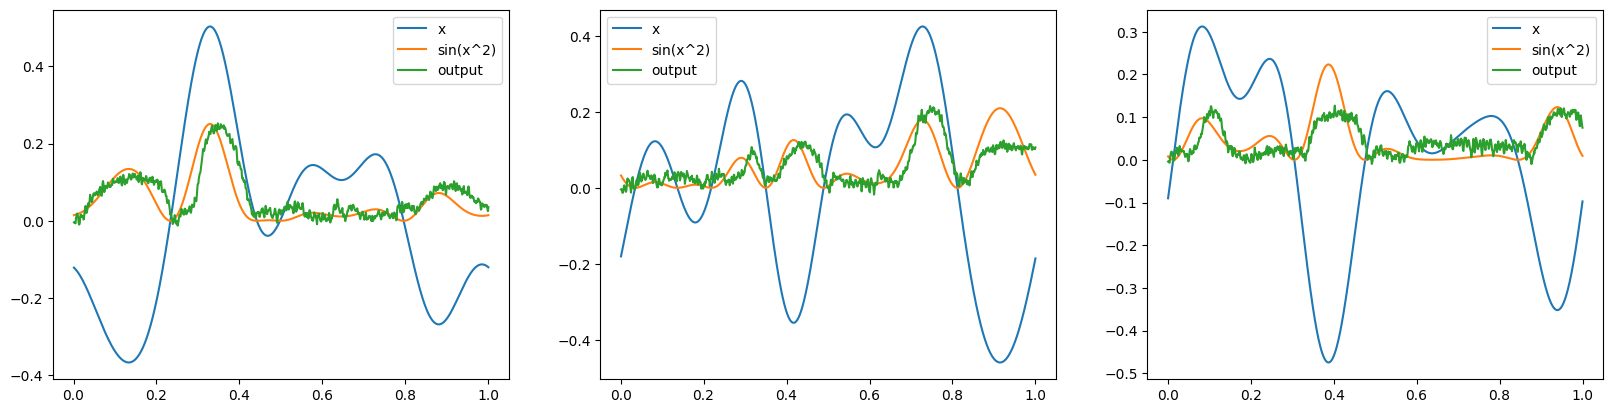

In [7]:
with nengo_dl.Simulator(net, minibatch_size=reps) as sim:
    sim.run(1.0)

_, axes = plt.subplots(1, reps, figsize=(20, 4.8))
for i in range(reps):
    plot(sim, ax=axes[i], idx=i)

Note that in this case the inputs and outputs aren't matching between the two simulators
because we're not worrying about controlling the random seed. But we can see that the
network has run three different simulations in a single parallel call.

## Specifying model inputs at run time

In standard Nengo, input values are specified in the model definition (when we create a
`nengo.Node`). NengoDL supports overriding these at run time through the `data` argument.
This is a dictionary mapping Nodes to arrays of shape `(n_steps, size)` for a single
trial, or `(batch, n_steps, size)` for a batched run:

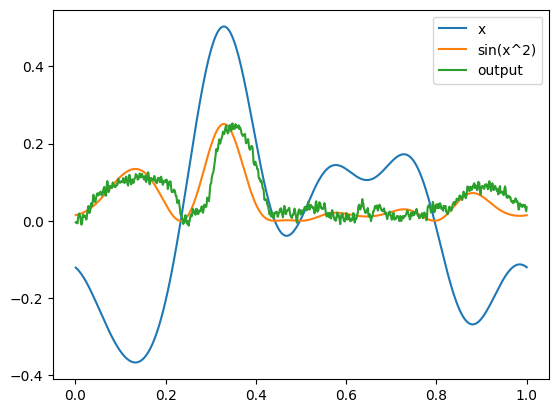

In [8]:
with nengo_dl.Simulator(net) as sim:
    sim.run(1.0, data={inpt: np.reshape(np.linspace(-1, 1, 1000), (1, 1000, 1))})

plot(sim)

Note that we didn't change the model definition at all. In theory, our Node is still
outputting the same random signal, but we overrode that with the values in `data`.

This is particularly useful with batch processing, as it allows us to provide different
input values for each item in the batch:

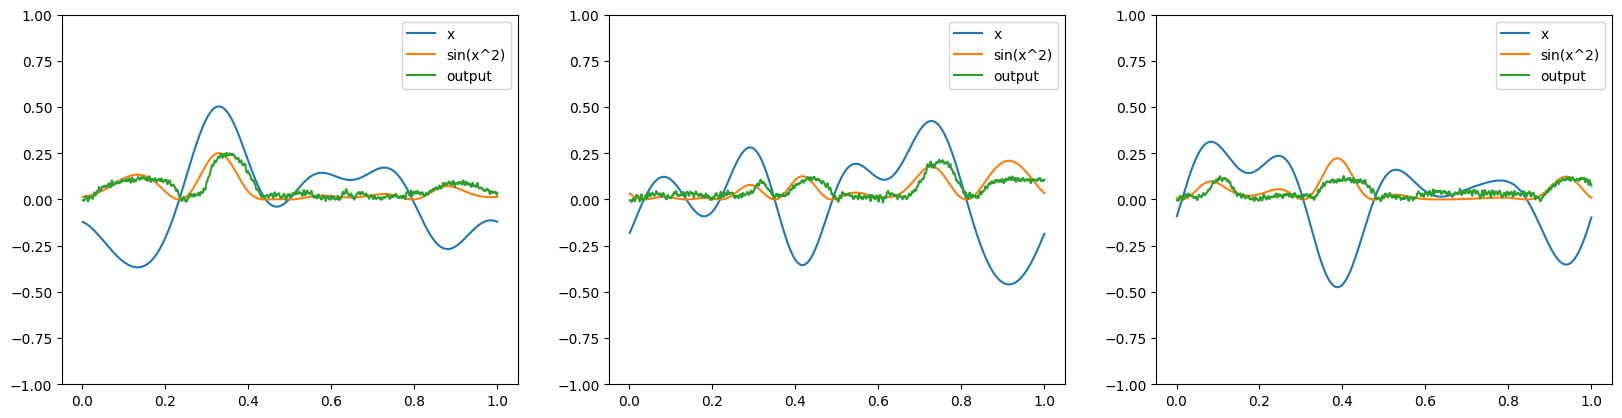

In [9]:
with nengo_dl.Simulator(net, minibatch_size=reps) as sim:
    sim.run(
        1.0,
        data={
            inpt: (
                np.linspace(0.5, 1, reps)[:, None, None]
                * np.linspace(-1, 1, 1000)[None, :, None]
            )
        },
    )

_, axes = plt.subplots(1, reps, figsize=(20, 4.8))
for i in range(reps):
    plot(sim, ax=axes[i], idx=i)
    axes[i].set_ylim((-1, 1))

## Optimizing model parameters

By default, Nengo uses the Neural Engineering Framework (NEF) to optimize the parameters
of a model. nengo-dl adds gradient-based training methods to that toolkit, which can be
used instead of or in addition to the NEF optimization.

Before training, we make two adjustments to the network:

1. **Remove synaptic filtering** from all connections (`synapse=None`) so the gradients
   see the instantaneous output.
2. **Add an unfiltered probe** `outpt_p_nofilt` for the loss, while keeping the filtered
   probe for visualisation.

In [10]:
# set all the connection synapses to None
for conn in net.all_connections:
    conn.synapse = None

# add a new probe that doesn't have a synaptic filter on it
# (we'll keep the original probe with the synaptic filter
# as well, since we'll have uses for both)
with net:
    outpt_p_nofilt = nengo.Probe(outpt)

# increase the filtering on our output probe (to compensate
# for the fact that we removed the internal synaptic filters)
outpt_p.synapse = 0.04

We can verify that our network still produces roughly the same output after these changes.

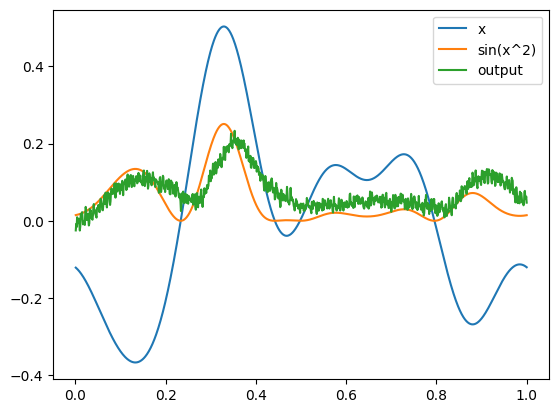

In [11]:
with nengo_dl.Simulator(net, seed=seed) as sim:
    sim.run(1.0)
    plot(sim)

Next we select which parameters to optimize. In this example we'll leave the decoders
fixed (as computed by the NEF) and only apply gradient-based training to the encoders
and biases. This is controlled through the `trainable` configuration attribute:

In [12]:
with net:
    # disable optimization on all parameters by default
    nengo_dl.configure_settings(trainable=False)

    # re-enable training on Ensembles (encoders and biases)
    net.config[nengo.Ensemble].trainable = True

Next we define our training data: input values for Nodes and target values for Probes.
Using `n_steps=1` means each sample is a single-timestep evaluation, which is efficient
for rate-coded training.

In [13]:
batch_size = 4096
minibatch_size = 32
n_steps = 1

# create random input data
vals = np.random.uniform(-1, 1, size=(batch_size, n_steps, 1))

# create data dictionaries
inputs = {inpt: vals}
targets = {outpt_p_nofilt: np.sin(vals**2)}

Now we are ready to optimize the model using `sim.compile` and `sim.fit`.

Epoch 1/100 — loss: 0.1321
Epoch 2/100 — loss: 0.1160
Epoch 3/100 — loss: 0.1039
Epoch 4/100 — loss: 0.0952
Epoch 5/100 — loss: 0.0898
Epoch 6/100 — loss: 0.0827
Epoch 7/100 — loss: 0.0809
Epoch 8/100 — loss: 0.0780
Epoch 9/100 — loss: 0.0781
Epoch 10/100 — loss: 0.0768
Epoch 11/100 — loss: 0.0763
Epoch 12/100 — loss: 0.0757
Epoch 13/100 — loss: 0.0747
Epoch 14/100 — loss: 0.0745
Epoch 15/100 — loss: 0.0751
Epoch 16/100 — loss: 0.0736
Epoch 17/100 — loss: 0.0731
Epoch 18/100 — loss: 0.0738
Epoch 19/100 — loss: 0.0730
Epoch 20/100 — loss: 0.0728
Epoch 21/100 — loss: 0.0731
Epoch 22/100 — loss: 0.0722
Epoch 23/100 — loss: 0.0729
Epoch 24/100 — loss: 0.0722
Epoch 25/100 — loss: 0.0721
Epoch 26/100 — loss: 0.0720
Epoch 27/100 — loss: 0.0716
Epoch 28/100 — loss: 0.0710
Epoch 29/100 — loss: 0.0719
Epoch 30/100 — loss: 0.0720
Epoch 31/100 — loss: 0.0713
Epoch 32/100 — loss: 0.0717
Epoch 33/100 — loss: 0.0716
Epoch 34/100 — loss: 0.0716
Epoch 35/100 — loss: 0.0720
Epoch 36/100 — loss: 0.0714
E

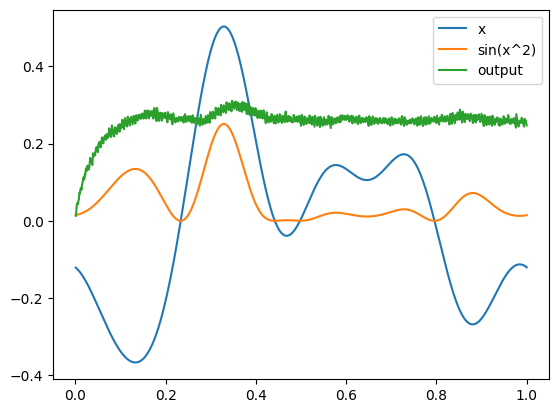

In [21]:
with nengo_dl.Simulator(net, minibatch_size=minibatch_size, seed=seed) as sim:
    sim.compile(
        optimizer=torch.optim.Adam(sim.trainable_params(), lr=0.0025),
        loss={outpt_p_nofilt: "mse"},
    )
    sim.fit(inputs, targets, epochs=100)

    sim.run(1.0)
    plot(sim, idx=0)

## Evaluating model performance

To evaluate how successful our training has been, we use `sim.evaluate` to compute the
loss before and after optimization on a held-out test set.

We'll also use a custom objective function that only looks at the last 10 timesteps of a
100-step sequence, to get a more meaningful measure of steady-state performance.

In [15]:
# create new set of random test data
test_vals = np.random.uniform(-1, 1, size=(1024, 1, 1))

In [16]:
# repeat test data for a number of timesteps
test_steps = 100
test_vals = np.tile(test_vals, (1, test_steps, 1))

# create test data dictionary
# note: using outpt_p instead of outpt_p_nofilt
test_inputs = {inpt: test_vals}
test_targets = {outpt_p: np.sin(test_vals**2)}

In [17]:
def test_mse(y_pred, y_true):
    # MSE on the last 10 timesteps only (ignoring startup transients)
    return torch.nn.functional.mse_loss(y_pred[:, -10:, :], y_true[:, -10:, :])

In [18]:
with nengo_dl.Simulator(net, minibatch_size=minibatch_size, seed=seed) as sim:
    sim.compile(loss={outpt_p: test_mse})
    print("Error before training:", sim.evaluate(test_inputs, test_targets, n_steps=test_steps)["loss"])

    # run the training, same as in the previous section
    print("Training")
    sim.compile(
        optimizer=torch.optim.Adam(sim.trainable_params(), lr=0.01),
        loss={outpt_p_nofilt: "mse"},
    )
    sim.fit(inputs, targets, epochs=25, verbose=0)

    sim.compile(loss={outpt_p: test_mse})
    print("Error after training:", sim.evaluate(test_inputs, test_targets, n_steps=test_steps)["loss"])

Error before training: 0.1282771343830973
Training
Error after training: 0.07419776811730117


## Integrating PyTorch code

Another important feature of nengo-dl is the ability to add PyTorch code directly into
a Nengo model via `TorchNode`. For example, we could embed a convolutional network
(defined in PyTorch) as the input to a Nengo cognitive model.

To keep things simple, we'll just use PyTorch to compute the exponent of our output, so
that the overall network computes $e^{\sin(x^2)}$. We compare this against the equivalent
plain `nengo.Node` implementation to verify they produce the same output:

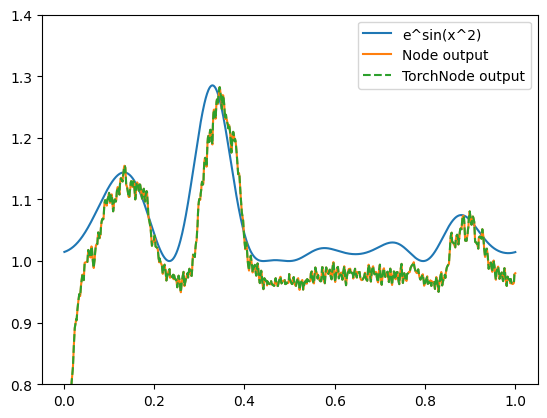

In [19]:
with net:
    # here is how we would accomplish this with a regular nengo Node
    exp_np = nengo.Node(lambda t, x: np.exp(x), size_in=1)
    nengo.Connection(outpt, exp_np)
    np_probe = nengo.Probe(exp_np, synapse=0.01)

    # here is how we do the same using a TorchNode
    class ExpModule(torch.nn.Module):
        def forward(self, x):
            return torch.exp(x)

    exp_torch = nengo_dl.TorchNode(ExpModule(), shape_in=(1,), shape_out=(1,))
    nengo.Connection(outpt, exp_torch)
    torch_probe = nengo.Probe(exp_torch, synapse=0.01)

with nengo_dl.Simulator(net, seed=seed) as sim:
    sim.run(1.0)

plt.figure()
plt.plot(sim.trange(), np.exp(np.sin(sim.data[inpt_p] ** 2)), label="e^sin(x^2)")
plt.plot(sim.trange(), sim.data[np_probe], label="Node output")
plt.plot(sim.trange(), sim.data[torch_probe], label="TorchNode output", linestyle="--")
plt.ylim([0.8, 1.4])
plt.legend()
plt.show()

We can see that the `nengo.Node` and `nengo_dl.TorchNode` produce the same output,
as expected. But under the hood, one is computed in NumPy and the other in PyTorch —
meaning gradients can flow through the `TorchNode` during `sim.fit()`, enabling
end-to-end training through custom PyTorch operations.